In [1]:
# -*- coding: utf-8 -*-
import os
import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
RDLogger.DisableLog('rdApp.*')

# =========================
# 0) 配置
# =========================
FOLD_DIR = "./best_xgb_5fold_saved"
N_FOLDS = 5
RANDOM_SEED = 42

# 你的原始总表（必须含 SMILES、特征列、标签列）
FEATURE_FILE_GLOB = "../Malodors_Rule&FG&Morgan&StructKG_features.xlsx"

# Morgan / Tanimoto 参数
RADIUS = 2
N_BITS = 2048
SIM_THRESH_LIST = np.arange(0.00, 1.0001, 0.05)
MIN_IN_SAMPLES = 1   # 这里建议先和你当前 AD-SAL 搜索脚本保持一致；若要更稳可改 5/30

# 输出
OUT_CSV = os.path.join(FOLD_DIR, "Tanimoto_AD_search_from_existing_npz.csv")


# =========================
# 1) 读取原始总表：只为了重建 split + 提取 SMILES
# =========================
def find_feature_file(pattern: str):
    cands = sorted(glob.glob(pattern))
    if not cands:
        raise FileNotFoundError(f"找不到特征文件：{pattern}")
    return cands[-1]

def find_smiles_col(df: pd.DataFrame):
    cand = [c for c in df.columns if isinstance(c, str) and "smiles" in c.lower()]
    if not cand:
        return df.columns[0]
    for p in ["Canonical SMILES", "canonical_smiles", "SMILES", "smiles"]:
        for c in cand:
            if c.lower() == p.lower():
                return c
    return cand[0]

def is_binary_01_series(s: pd.Series) -> bool:
    if s.dtype == bool:
        return True
    if not np.issubdtype(s.dtype, np.number):
        return False
    vals = pd.unique(s.dropna())
    if len(vals) == 0:
        return False
    return set(vals).issubset({0, 1})

def infer_feature_cols_morgan(df: pd.DataFrame):
    cols = []
    for prefix in ["Rule__", "FG__", "morgan_", "fp_", "ecfp_", "mfp_", "bit_", "KG_emb_"]:
        cols.extend([c for c in df.columns if isinstance(c, str) and c.startswith(prefix)])
    if cols:
        return list(cols)

    num_cols = []
    for c in df.columns:
        if isinstance(c, (int, np.integer)):
            num_cols.append(c)
        elif isinstance(c, str) and c.isdigit():
            num_cols.append(c)
    if num_cols:
        return sorted(num_cols, key=lambda x: int(x))

    raise ValueError("未找到特征列。")

def infer_label_cols(df: pd.DataFrame, smiles_col: str, feature_cols: list):
    exclude = set(feature_cols)
    if smiles_col is not None:
        exclude.add(smiles_col)

    label_cols = []
    for c in df.columns:
        if c in exclude:
            continue
        if is_binary_01_series(df[c]):
            label_cols.append(c)

    if not label_cols:
        raise ValueError("未识别到标签列（0/1）。")
    return label_cols

def load_Xy_smiles_from_transformed_file(xlsx_path: str):
    df = pd.read_excel(xlsx_path)

    smiles_col = find_smiles_col(df)
    feature_cols = infer_feature_cols_morgan(df)
    label_cols = infer_label_cols(df, smiles_col, feature_cols)

    X = df[feature_cols].fillna(0).astype(np.float32).values
    y = df[label_cols].fillna(0).astype(int).values
    smiles = df[smiles_col].astype(str).values

    if not (len(X) == len(y) == len(smiles)):
        raise ValueError("X / y / SMILES 行数不一致。")

    return X, y, smiles, feature_cols, label_cols, df, smiles_col


# =========================
# 2) 与你保存代码一致的折划分方式
# =========================
def make_stratify_target(y: np.ndarray, n_bins: int = 10):
    card = y.sum(axis=1).astype(int)
    uniq = np.unique(card)
    if len(uniq) <= 15:
        return card
    r = pd.Series(card).rank(method="average").values
    bins = pd.qcut(r, q=min(n_bins, len(np.unique(r))), labels=False, duplicates="drop")
    return np.asarray(bins, dtype=int)

def build_folds(X, y, n_splits=5, seed=42):
    strat_y = make_stratify_target(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(skf.split(X, strat_y))


# =========================
# 3) 读取现有 fold npz（不重训）
# =========================
def load_fold_npz(fold_id: int):
    path = os.path.join(FOLD_DIR, f"fold_{fold_id:02d}.npz")
    z = np.load(path, allow_pickle=True)
    return z["X_tr"], z["y_tr"], z["X_va"], z["y_va"], z["y_prob_va"]


# =========================
# 4) Tanimoto 工具
# =========================
def smiles_to_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

def batch_smiles_to_fps(smiles_list, radius=2, n_bits=2048):
    fps = []
    valid_idx = []
    for i, smi in enumerate(smiles_list):
        fp = smiles_to_morgan_fp(smi, radius=radius, n_bits=n_bits)
        if fp is not None:
            fps.append(fp)
            valid_idx.append(i)
    return fps, np.array(valid_idx, dtype=int)

def max_tanimoto_similarity_to_train(test_fps, train_fps):
    max_sims = np.zeros(len(test_fps), dtype=np.float32)
    for i, fp_te in enumerate(test_fps):
        sims = DataStructs.BulkTanimotoSimilarity(fp_te, train_fps)
        max_sims[i] = np.max(sims) if len(sims) > 0 else 0.0
    return max_sims


# =========================
# 5) AUPRC 工具
# =========================
def per_label_ap(y_true, y_prob):
    y_true = np.asarray(y_true).astype(np.int8)
    y_prob = np.asarray(y_prob).astype(np.float32)
    L = y_true.shape[1]
    ap = np.full(L, np.nan, dtype=float)
    for j in range(L):
        yt = y_true[:, j]
        if len(np.unique(yt)) < 2:
            continue
        ap[j] = average_precision_score(yt, y_prob[:, j])
    return ap

def macro_auprc_with_baseline_fill(y_true_in, y_prob_in, ap_baseline, label_idx):
    ap_in = per_label_ap(y_true_in, y_prob_in)
    ap_filled = ap_in.copy()
    nan_mask = np.isnan(ap_filled)
    ap_filled[nan_mask] = ap_baseline[nan_mask]
    return float(np.mean(ap_filled[label_idx]))


# =========================
# 6) 主流程
# =========================
def main():
    # ---- 6.1 从原始总表读取 X / y / smiles，仅用于重建 split ----
    feature_file = find_feature_file(FEATURE_FILE_GLOB)
    print("[INFO] feature file:", feature_file)

    X_all, y_all, smiles_all, feat_cols, label_cols, df_all, smiles_col = load_Xy_smiles_from_transformed_file(feature_file)
    print(f"[INFO] X={X_all.shape}, y={y_all.shape}, smiles_col={smiles_col}")

    # ---- 6.2 重建与你训练/保存代码一致的 5 折 ----
    folds = build_folds(X_all, y_all, n_splits=N_FOLDS, seed=RANDOM_SEED)
    print(f"[INFO] reconstructed {len(folds)} folds")

    fold_cache = []
    all_scores = []

    # ---- 6.3 每折：读取现有 npz，并从总表提取对应 smiles_tr / smiles_va ----
    for fold_id, (tr_idx, va_idx) in enumerate(folds, start=1):
        X_tr_npz, y_tr_npz, X_va_npz, y_va_npz, y_prob_va = load_fold_npz(fold_id)

        # 用重建 split 取得 SMILES
        smiles_tr = smiles_all[tr_idx]
        smiles_va = smiles_all[va_idx]

        # 用重建 split 取得 y（只用于一致性检查，可不强求逐元素完全相同）
        y_tr = y_all[tr_idx]
        y_va = y_all[va_idx]

        # ---- 长度一致性检查 ----
        if len(y_tr_npz) != len(smiles_tr):
            raise ValueError(
                f"fold {fold_id}: npz训练集长度={len(y_tr_npz)}，重建split训练集长度={len(smiles_tr)}，不一致。"
            )
        if len(y_va_npz) != len(smiles_va):
            raise ValueError(
                f"fold {fold_id}: npz验证集长度={len(y_va_npz)}，重建split验证集长度={len(smiles_va)}，不一致。"
            )
        if y_prob_va.shape[0] != len(smiles_va):
            raise ValueError(
                f"fold {fold_id}: y_prob_va行数={y_prob_va.shape[0]}，验证集SMILES数={len(smiles_va)}，不一致。"
            )

        # ---- 可选：检查标签矩阵是否一致（不一致就说明 split 顺序没对上）----
        if y_va.shape == y_va_npz.shape:
            same_ratio = np.mean(y_va == y_va_npz)
            print(f"[INFO] fold {fold_id}: y_va match ratio = {same_ratio:.6f}")

        # ---- 转 Morgan 指纹 ----
        train_fps, tr_valid_idx = batch_smiles_to_fps(smiles_tr, radius=RADIUS, n_bits=N_BITS)
        val_fps, va_valid_idx   = batch_smiles_to_fps(smiles_va, radius=RADIUS, n_bits=N_BITS)

        # 同步去掉无效 SMILES
        if len(tr_valid_idx) != len(smiles_tr):
            y_tr_npz = y_tr_npz[tr_valid_idx]
            smiles_tr = smiles_tr[tr_valid_idx]

        if len(va_valid_idx) != len(smiles_va):
            y_va_npz = y_va_npz[va_valid_idx]
            y_prob_va = y_prob_va[va_valid_idx]
            smiles_va = smiles_va[va_valid_idx]

        # ---- 计算传统 Tanimoto AD 分数：max similarity ----
        max_sims = max_tanimoto_similarity_to_train(val_fps, train_fps)

        fold_cache.append({
            "fold_id": fold_id,
            "y_va": y_va_npz,
            "y_prob_va": y_prob_va,
            "smiles_tr": smiles_tr,
            "smiles_va": smiles_va,
            "max_sims": max_sims,
        })
        all_scores.append(max_sims)

        print(f"[INFO] fold {fold_id}: train={len(smiles_tr)}, val={len(smiles_va)}")

    all_scores = np.concatenate(all_scores)

    # ---- 6.4 baseline AP（跨所有 fold 验证集）----
    Y_all = np.concatenate([fc["y_va"] for fc in fold_cache], axis=0)
    P_all = np.concatenate([fc["y_prob_va"] for fc in fold_cache], axis=0)

    ap_baseline = per_label_ap(Y_all, P_all)
    label_idx = np.array([j for j in range(Y_all.shape[1]) if not np.isnan(ap_baseline[j])], dtype=int)
    print(f"[INFO] evaluable labels: {len(label_idx)}/{Y_all.shape[1]}")

    # ---- 6.5 阈值扫描 ----
    rows = []
    best_ap = -np.inf
    best_cov = np.nan
    best_th = np.nan

    for sim_th in SIM_THRESH_LIST:
        n_list = []
        cov_list = []
        ap_list = []

        s_ap = 0.0
        cnt_fold = 0
        cov_sum = 0.0

        for fc in fold_cache:
            max_sims = fc["max_sims"]
            y_va = fc["y_va"]
            y_prob_va = fc["y_prob_va"]

            in_m = (max_sims >= sim_th)
            n_in = int(in_m.sum())
            cov = n_in / len(max_sims) if len(max_sims) > 0 else np.nan

            n_list.append(n_in)
            cov_list.append(cov)

            if n_in >= MIN_IN_SAMPLES:
                ap_in = macro_auprc_with_baseline_fill(
                    y_va[in_m], y_prob_va[in_m], ap_baseline, label_idx
                )
                ap_list.append(ap_in)

                s_ap += ap_in
                cnt_fold += 1
                cov_sum += cov
            else:
                ap_list.append(np.nan)

        mean_n = float(np.mean(n_list))
        mean_cov = float(np.mean(cov_list))
        mean_ap_surface = float(np.nanmean(ap_list)) if np.any(np.isfinite(ap_list)) else np.nan

        if cnt_fold > 0:
            mean_ap_search = s_ap / cnt_fold
            mean_cov_search = cov_sum / cnt_fold
        else:
            mean_ap_search = np.nan
            mean_cov_search = np.nan

        rows.append({
            "sim_th": float(sim_th),
            "mean_count_in": mean_n,
            "mean_coverage_in": mean_cov,
            "mean_AUPRC_in_surface": mean_ap_surface,
            "mean_AUPRC_in_search": mean_ap_search,
            "mean_coverage_in_search": mean_cov_search,
            "MIN_IN_SAMPLES": int(MIN_IN_SAMPLES),
            "radius": int(RADIUS),
            "n_bits": int(N_BITS),
        })

        print(f"[TH={sim_th:>4.2f}] AUPRC_in={mean_ap_search:.6f} | cov={mean_cov_search:.4f} | n={mean_n:.1f}")

        if np.isfinite(mean_ap_search) and (mean_ap_search > best_ap):
            best_ap = mean_ap_search
            best_cov = mean_cov_search
            best_th = float(sim_th)

    result_df = pd.DataFrame(rows)
    result_df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

    print("\n" + "=" * 90)
    print(f"[BEST] sim_th={best_th:.6f}, AUPRC_in={best_ap:.6f}, coverage={best_cov:.6f}")
    print(f"[SAVED] {OUT_CSV}")
    print("=" * 90)


if __name__ == "__main__":
    main()

[INFO] feature file: ../Malodors_Rule&FG&Morgan&StructKG_features.xlsx
[INFO] X=(3756, 2048), y=(3756, 554), smiles_col=Canonical_SMILES
[INFO] reconstructed 5 folds
[INFO] fold 1: train=3004, val=752
[INFO] fold 2: train=3005, val=751
[INFO] fold 3: train=3005, val=751
[INFO] fold 4: train=3005, val=751
[INFO] fold 5: train=3005, val=751
[INFO] evaluable labels: 24/24
[TH=0.00] AUPRC_in=0.436789 | cov=1.0000 | n=751.2
[TH=0.05] AUPRC_in=0.436789 | cov=1.0000 | n=751.2
[TH=0.10] AUPRC_in=0.436789 | cov=1.0000 | n=751.2
[TH=0.15] AUPRC_in=0.436789 | cov=1.0000 | n=751.2
[TH=0.20] AUPRC_in=0.436745 | cov=0.9992 | n=750.6
[TH=0.25] AUPRC_in=0.437614 | cov=0.9944 | n=747.0
[TH=0.30] AUPRC_in=0.438500 | cov=0.9816 | n=737.4
[TH=0.35] AUPRC_in=0.438672 | cov=0.9571 | n=719.0
[TH=0.40] AUPRC_in=0.440869 | cov=0.9201 | n=691.2
[TH=0.45] AUPRC_in=0.443646 | cov=0.8698 | n=653.4
[TH=0.50] AUPRC_in=0.448105 | cov=0.8094 | n=608.0
[TH=0.55] AUPRC_in=0.454281 | cov=0.7002 | n=526.0
[TH=0.60] AUPRC_

[BEST] sim_th=0.900, AUPRC_in=0.518913, count=104.8, coverage=0.139508
[SAVED] ./best_xgb_5fold_saved/Tanimoto_Count_AUPRC_in_one_figure.png


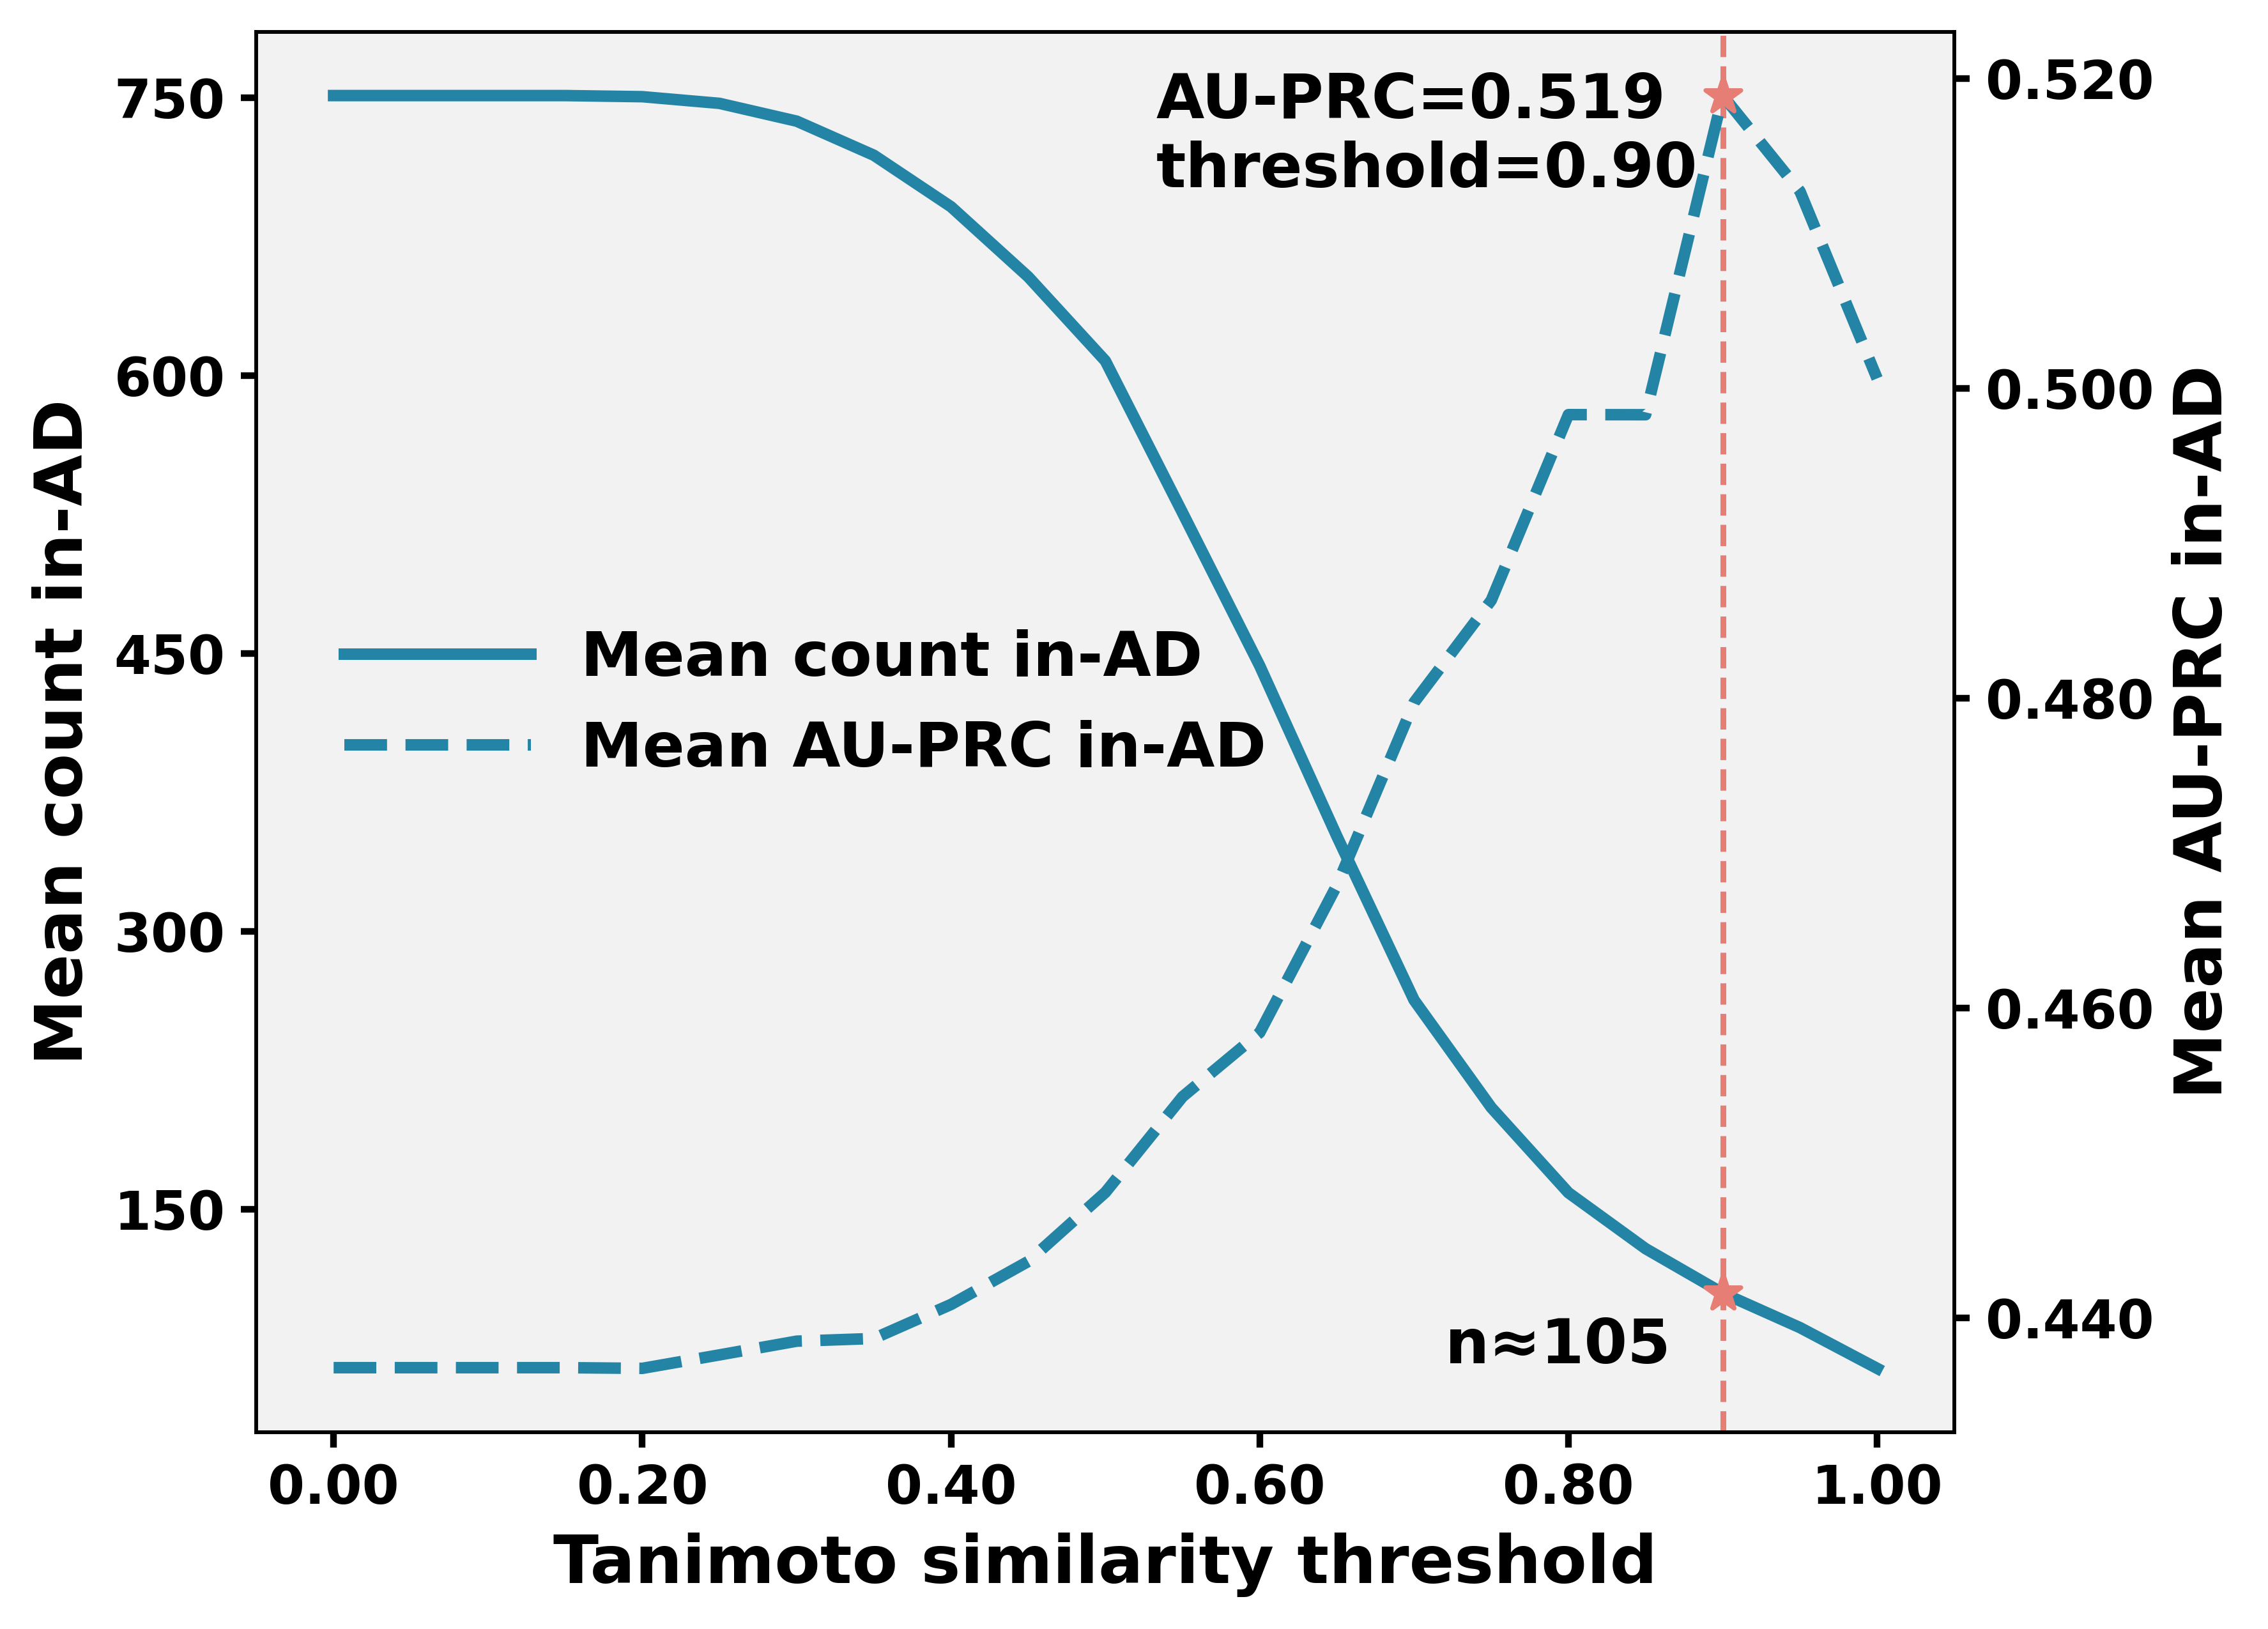

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

# =========================
# 0) 配置
# =========================
IN_CSV = "./best_xgb_5fold_saved/Tanimoto_AD_search_from_existing_npz.csv"
SAVE_FIG = True
OUT_FIG = "./best_xgb_5fold_saved/Tanimoto_Count_AUPRC_in_one_figure.png"

BG_COLOR = "#F2F2F2"   # 只用于坐标轴方框内部的浅灰色

# =========================
# 1) 读取数据
# =========================
df = pd.read_csv(IN_CSV)

valid = df["mean_AUPRC_in_search"].notna()
if valid.sum() == 0:
    raise RuntimeError("CSV 中没有可用的 mean_AUPRC_in_search 结果。")

best_idx = df.loc[valid, "mean_AUPRC_in_search"].idxmax()
best_row = df.loc[best_idx]

best_th  = float(best_row["sim_th"])
best_ap  = float(best_row["mean_AUPRC_in_search"])
best_n   = float(best_row["mean_count_in"])
best_cov = float(best_row["mean_coverage_in_search"])

print(f"[BEST] sim_th={best_th:.3f}, AUPRC_in={best_ap:.6f}, count={best_n:.1f}, coverage={best_cov:.6f}")

# =========================
# 2) 同一张图：Count + AU-PRC
# =========================
fig, ax1 = plt.subplots(figsize=(7.2, 5.2), dpi=500)

# ---- 只设置坐标轴方框内部背景色 ----
ax1.set_facecolor(BG_COLOR)

# ---- 左轴：Count ----
line1 = ax1.plot(
    df["sim_th"], df["mean_count_in"],
    linewidth=2.6,
    color="#2384A6",
    label="Mean count in-AD"
)
ax1.scatter(
    [best_th], [best_n],
    color="#E67E76", s=70, marker="*", zorder=10
)

ax1.set_xlabel("Tanimoto similarity threshold", fontsize=15, fontweight="bold")
ax1.set_ylabel("Mean count in-AD", fontsize=15, fontweight="bold")

ax1.tick_params(axis='both', labelsize=12, width=1.5)
for t in ax1.get_xticklabels() + ax1.get_yticklabels():
    t.set_fontweight("bold")

ax1.xaxis.set_major_locator(MaxNLocator(6))
ax1.yaxis.set_major_locator(MaxNLocator(6))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

# 最优阈值竖线
ax1.axvline(best_th, color="#E67E76", linestyle="--", linewidth=1.3)

# ---- 右轴：AU-PRC ----
ax2 = ax1.twinx()
ax2.set_facecolor("none")   # 保持透明，不覆盖 ax1 的浅灰背景

line2 = ax2.plot(
    df["sim_th"], df["mean_AUPRC_in_surface"],
    linewidth=2.6,
    color="#2384A6",
    linestyle="--",
    label="Mean AU-PRC in-AD"
)
ax2.scatter(
    [best_th], [best_ap],
    color="#E67E76", s=70, marker="*", zorder=10
)

ax2.set_ylabel("Mean AU-PRC in-AD", fontsize=15, fontweight="bold")
ax2.tick_params(axis='y', labelsize=12, width=1.5)
for t in ax2.get_yticklabels():
    t.set_fontweight("bold")

ax2.yaxis.set_major_locator(MaxNLocator(6))
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

# =========================
# 3) 图例：固定放图内左侧，不与曲线重叠
# =========================
lines = line1 + line2
labels = [l.get_label() for l in lines]
leg = ax1.legend(
    lines, labels,
    loc="upper left",
    bbox_to_anchor=(0.03, 0.60),
    frameon=False,
    fontsize=14,
    handlelength=3.0,
    borderaxespad=0.2
)
for txt in leg.get_texts():
    txt.set_fontweight("bold")

# =========================
# 4) 红色说明：固定放图内，不在图外
# =========================
ax1.text(
    0.53, 0.88,
    f"AU-PRC={best_ap:.3f}\nthreshold={best_th:.2f}",
    transform=ax1.transAxes,
    color="black",
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="bottom"
)

ax1.text(
    0.70, 0.04,
    f"n≈{int(round(best_n))}",
    transform=ax1.transAxes,
    color="black",
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="bottom"
)

plt.tight_layout()
if SAVE_FIG:
    fig.savefig(OUT_FIG, bbox_inches="tight")
    print("[SAVED]", OUT_FIG)
plt.show()